# Advanced Linear Models

## Introduction

In our previous notebooks, we've explored the Ames housing dataset, performed data preprocessing, and applied basic linear models. We've also examined cross-validation techniques and principal component analysis. Now, we'll dive deeper into the mathematics behind linear models and explore more advanced concepts.

This notebook covers:
1. The mathematics of loss functions in linear models
2. Finding minima using calculus
3. How logistic regression works as a linear model
4. Introduction to gradient descent

Understanding these concepts will provide a foundation for the regularization techniques we'll explore in the next notebook.

## Loss Functions in Linear Models

### In Algebra I

$$y = mx + b$$

$$f(x) = mx + b$$

$$f(x) = \beta_0 + \beta_1x + \dots + \beta_{1.5E9}x$$

We would be given a function and a set of inputs. Your task is to compute the outputs.


### In Machine Learning

We have inputs ($X$) and outputs ($y$), typically from measuring data in the world. Some observable phenomenon.

We seek to find the best function that maps inputs to outputs. There is some unknowable function that describes the relationship between $X$ and $y$, $f$. We're looking for $\hat{f}$ that best approximates $f$.

$$y = f(X) + \epsilon$$

We want

$$\hat{f}(X) = X\beta = \hat{y} \approx y$$

We seek to find the best $\beta$ that minimizes the loss between $\hat{y}$ and $y$.


In general, linear models are fit by minimizing a loss function. This function will be a function of the $\beta$ coefficients for each feature. The best set of $\beta$ values is the set that gives the smallest value of the loss function. 

The most common loss function is the sum of squared errors (SSE), also known as the residual sum of squares (RSS):

$$\mathcal{L}(\beta) = \sum_{i=1}^n \left(y_i - \widehat{y}_i\right)^2 = (y-X\beta)^T(y-X\beta)$$

Where:
- $y_i$ is the actual value for observation $i$
- $\widehat{y}_i$ is the predicted value for observation $i$
- $X$ is the matrix of features
- $\beta$ is the vector of coefficients

Generally speaking, this equation is a second-degree polynomial or quadratic. 

If we had one feature, then we would be seeking the best line:

$$\widehat{f} = \beta_0 + \beta_1x$$

The loss $\mathcal{L}$ as a function of $\beta_1$ would be the familiar parabola shape:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression

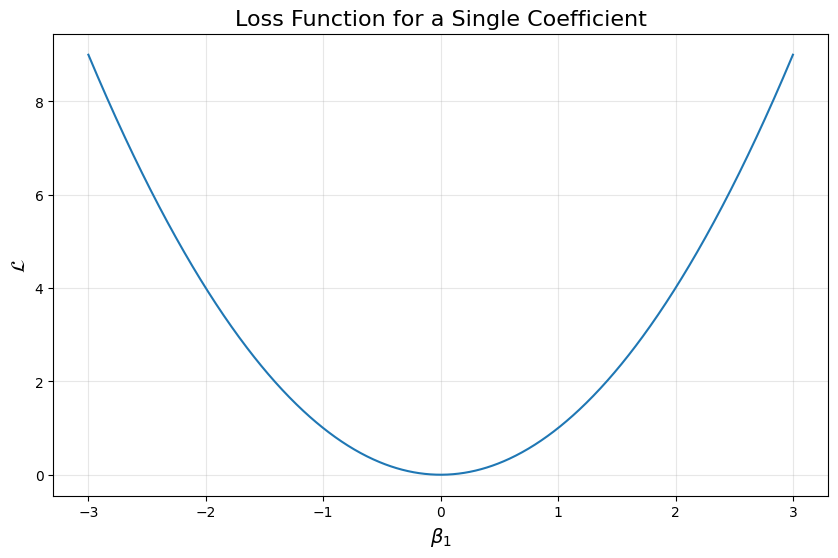

In [2]:
# Visualize the loss function for a simple case with one coefficient
bbeta = np.linspace(-3,3,1000)
lloss = bbeta**2
plt.figure(figsize=(10, 6))
plt.plot(bbeta, lloss)
plt.xlabel('$\\beta_1$', fontsize=14)
plt.ylabel('$\\mathcal{L}$', fontsize=14)
plt.title('Loss Function for a Single Coefficient', fontsize=16)
plt.grid(True, alpha=0.3)

If we were to plot the loss versus $\beta_0$ and $\beta_1$, it would be a 3-D paraboloid where the height of the paraboloid is the associated loss $\mathcal{L}$

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/1/12/Paraboloid_of_Revolution.svg/512px-Paraboloid_of_Revolution.svg.png" width=300px>

This would generalize to higher dimensions. The important thing is that there is always a single **global** minimum i.e. *the loss function is convex*.

For linear regression with the squared error loss function, this convexity guarantees that we can find the global minimum. This is a key property that makes linear regression mathematically tractable.

## Finding a Minimum Using Calculus

Given a parabol(oid), we can find the minimum using calculus. Recall that the derivative of a function represents the rate of change (slope) of the function at a given point.

For a function with a single variable, the minimum occurs where the derivative equals zero. For a function with multiple variables (like our loss function with multiple coefficients), we need to find where all partial derivatives equal zero.

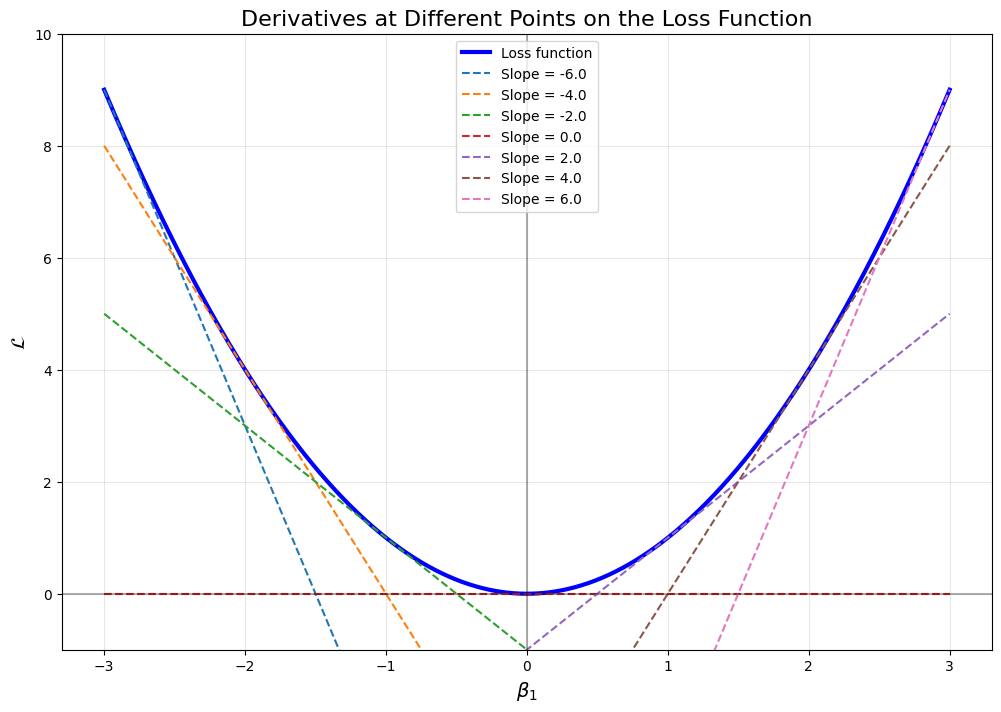

In [3]:
# Visualize the slopes (derivatives) at different points on the loss function
bbeta = np.linspace(-3,3,1000)
lloss = bbeta**2

# Create test points and calculate their slopes and loss values
test_points = np.linspace(-3,3,7)
slopes = 2*test_points  # The derivative of x² is 2x
losses = test_points**2

# Function to create tangent lines
def slope_line(m, x, x1, y1):
    return m*(x - x1) + y1

# Plot the loss function and tangent lines
plt.figure(figsize=(12, 8))
plt.plot(bbeta, lloss, 'b-', linewidth=3, label='Loss function')
for m, x1, y1 in zip(slopes, test_points, losses):
    plt.plot(bbeta, slope_line(m, bbeta, x1, y1), '--', label=f'Slope = {m}')
plt.ylim(-1, 10)
plt.legend()
plt.xlabel('$\\beta_1$', fontsize=14)
plt.ylabel('$\\mathcal{L}$', fontsize=14)
plt.title('Derivatives at Different Points on the Loss Function', fontsize=16)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

Using Calculus, we can find the minimum of our loss function by finding where the slope is zero. In other words, we can find the minimum of the loss function by finding where the derivative of the loss function is zero.

For linear regression with the squared error loss function, we can derive the closed-form solution:

$$\frac{d\mathcal{L}(\beta)}{d\beta} = -2X^T(y - X\beta) = 0$$

$$-2X^T(y - X\beta) = 0$$
$$X^T(y - X\beta) = 0$$

Solving for $\beta$:

$$X^TX\beta = X^Ty$$
$$(X^TX)^{-1}X^TX\beta = (X^TX)^{-1}X^Ty$$
$$I\beta = (X^TX)^{-1}X^Ty$$
$$\beta = (X^TX)^{-1}X^Ty$$

This is the well-known "normal equation" for linear regression. It gives us the exact solution for the coefficients that minimize the loss function.

However, not all loss functions have such convenient closed-form solutions. For example, in logistic regression, we need to use iterative optimization methods like gradient descent.

Linear regression is a regression model. We are predicting a continuous numerical output.

Logistic regression is a classification model. We are predicting a categorical output.

## How Logistic Regression Works as a Linear Model

Logistic regression is used for classification problems, but it's still considered a linear model. This might seem counterintuitive since the decision boundary is not linear in the probability space. Let's explore why logistic regression is still a linear model and how it works.

In [4]:
# Create a simple dataset with two classes
X, y = make_blobs(centers=2, random_state=42, n_samples=200)
X = pd.DataFrame(X)

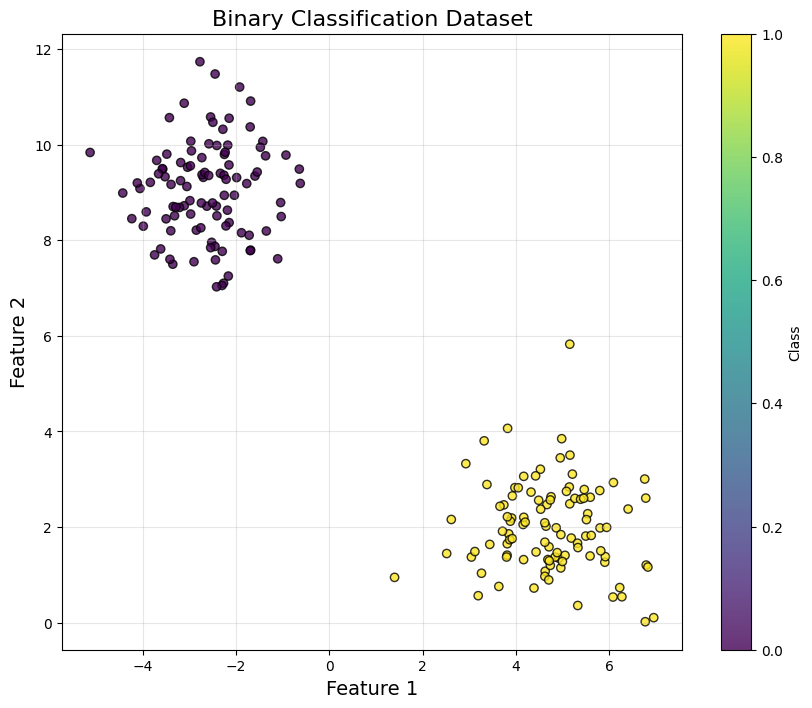

In [5]:
# Visualize the data
plt.figure(figsize=(10, 8))
plt.scatter(X[0], X[1], c=y, cmap='viridis', alpha=0.8, edgecolors='k')
plt.title('Binary Classification Dataset', fontsize=16)
plt.xlabel('Feature 1', fontsize=14)
plt.ylabel('Feature 2', fontsize=14)
plt.colorbar(label='Class')
plt.grid(True, alpha=0.3)

The linear part for two variables would be 

$$\hat{f} = \beta_0 + \beta_1x_1 + \beta_2x_2$$

This is a linear equation in the feature space.

The decision boundary is the set of points where $\hat{f} = 0$.



In [8]:
# Fit a logistic regression model
lr = LogisticRegression()
lr.fit(X, y)

# Print the model coefficients
print(f"Intercept β₀: {lr.intercept_[0]:.4f}")
print(f"Coefficient β₁ for feature 1: {lr.coef_[0][0]:.4f}")
print(f"Coefficient β₂ for feature 2: {lr.coef_[0][1]:.4f}")

Intercept β₀: 4.2340
Coefficient β₁ for feature 1: 1.0427
Coefficient β₂ for feature 2: -0.9498


In [9]:
# Extract the coefficients and intercept
coef = lr.coef_[0]
intercept = lr.intercept_[0]

print("The decision boundary equation is:")
print(f"{coef[0]:.4f} * x1 + {coef[1]:.4f} * x2 + {intercept:.4f} = 0")

The decision boundary equation is:
1.0427 * x1 + -0.9498 * x2 + 4.2340 = 0


In [10]:
# Calculate the decision boundary line
A = lr.coef_[0][0]
B = lr.coef_[0][1]
C = lr.intercept_[0]

# Create points for the decision boundary line
xx = np.linspace(min(X[0])-1, max(X[0])+1, 100)
def y_hat(x):
    return -A/B*x - C/B  # Rearranging the equation: A*x + B*y + C = 0 to y = -A/B*x - C/B

In [11]:
# Add polynomial features to demonstrate that we can create non-linear decision boundaries
# with a linear model by transforming the feature space
X[2] = X[0]**2  # Square of feature 1
X[3] = X[1]**2  # Square of feature 2
X[4] = X[0]*X[1]  # Interaction term

Text(0.5, 0.01, 'The decision boundary is linear in the feature space.\nPoints above the line are classified as one class, points below as the other.')

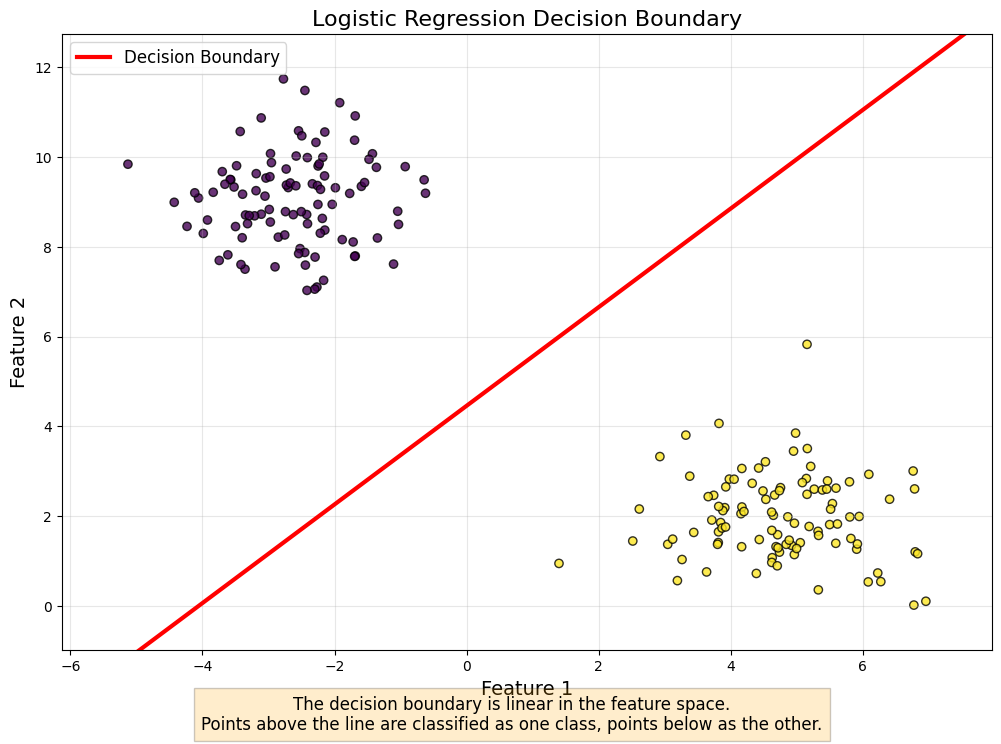

In [12]:
# Plot the data points and the decision boundary
plt.figure(figsize=(12, 8))
plt.scatter(X[0], X[1], c=y, cmap='viridis', alpha=0.8, edgecolors='k')
plt.plot(xx, y_hat(xx), 'r-', linewidth=3, label='Decision Boundary')
plt.title('Logistic Regression Decision Boundary', fontsize=16)
plt.xlabel('Feature 1', fontsize=14)
plt.ylabel('Feature 2', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xlim(min(X[0])-1, max(X[0])+1)
plt.ylim(min(X[1])-1, max(X[1])+1)

# Add explanation text
plt.figtext(0.5, 0.01, 
           "The decision boundary is linear in the feature space.\n"
           "Points above the line are classified as one class, points below as the other.",
           ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})

The goal with logistic regression is to find the line that "best splits" the data. 

## The Logistic Function

In logistic regression, we're still using a linear combination of features:

$$z = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$$

But instead of directly using this as our prediction (as in linear regression), we pass it through the logistic function (sigmoid):

$$\widehat{p} = \frac{1}{1 + e^{-z}}$$

$$\widehat{p} = \frac{1}{1 + e^{-\beta_0 - \beta_1x_1 - \beta_2x_2 - ... - \beta_nx_n}}$$

This transforms our output to be between 0 and 1, which we can interpret as a probability.

For classification, we typically use a threshold (usually 0.5) to convert this probability to a class label:

$$ \text{Class}(x) = \left\{
     \begin{array}{lr}
       1 & : \widehat{p} > 0.5\\
       0 & : \widehat{p} \leq 0.5
     \end{array}
   \right.
$$

This might look like:

In [13]:
# Demonstrate a simple linear function and its thresholded version
xx = np.linspace(-3, 3, 1000)
def y_hat(x):
    return 1 + 0.5*x  # Linear function

def cls(x):
    return np.piecewise(x, [y_hat(x) > 0.5, y_hat(x) <= 0.5], [1, 0])  # Thresholded version

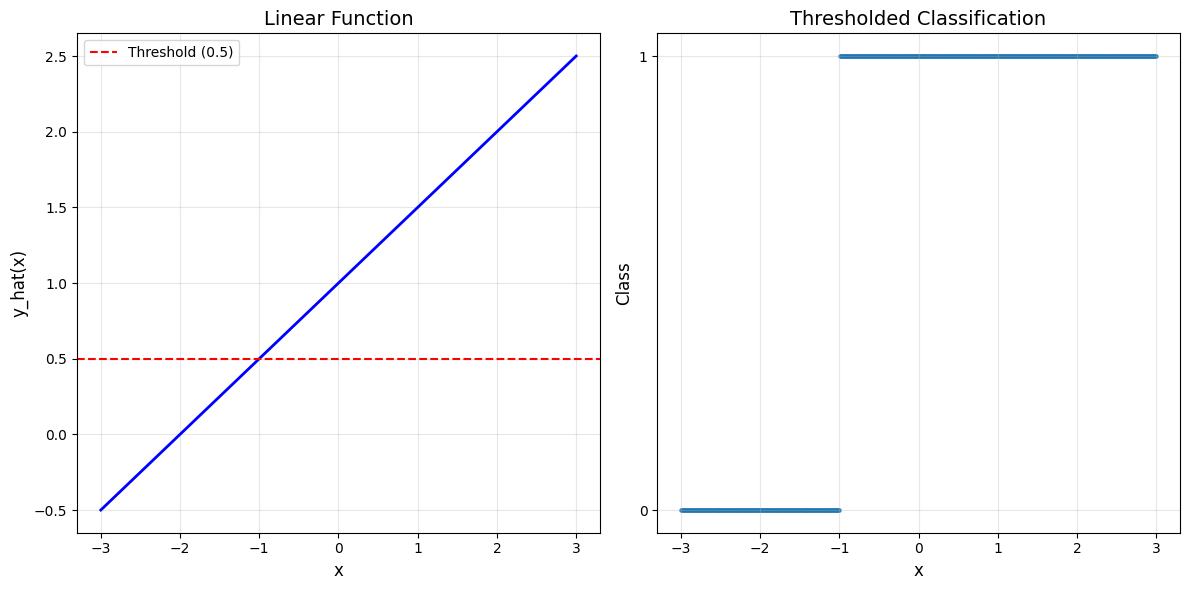

In [14]:
# Plot the linear function and its thresholded version
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(xx, y_hat(xx), 'b-', linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', label='Threshold (0.5)')
plt.title('Linear Function', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y_hat(x)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(xx, cls(xx), s=5, alpha=0.5)
plt.title('Thresholded Classification', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.yticks([0, 1])
plt.grid(True, alpha=0.3)

plt.tight_layout()

## The Problem with a Simple Threshold

There is an issue with using a simple threshold function for classification. The most common loss function is:

$$\mathcal{L}(\beta) = \sum_{i=1}^n \left(y_i - \widehat{y}_i\right)^2 = (y-X\beta)^T(y-X\beta)$$

Here the possible values of $y$ are the possible classes, that is $y \in \{0,1\}$.

If we use a simple threshold, the possible values of $\widehat{y}$ are also the possible classes, that is $\widehat{y} \in \{0,1\}$.

The implications of this are that the loss function is not continuous and more importantly the derivative has points at which it is not defined. **We cannot use calculus to solve this problem directly**.

This is because the threshold function creates "jumps" in the output, making the function non-differentiable at the threshold points.

This led to two innovations that are fundamental to modern machine learning (and especially deep learning):

1. The sigmoid function (for smooth, differentiable outputs)
2. Gradient descent (for iterative optimization)

These innovations allow us to optimize models even when we don't have a closed-form solution.

### The Sigmoid Function

The sigmoid function is a way to make the logistic regression equation continuous and differentiable. Instead of using a hard threshold:

$$ \widehat{f}(x) = \left\{
     \begin{array}{lr}
       1 & : \beta_0 + \beta_1x > 0.5\\
       0 & : \beta_0 + \beta_1x \leq 0.5
     \end{array}
   \right.
$$

We use the sigmoid function:

$$\sigma(z) = \frac{1}{1+e^{-z}}$$

To build our logistic regression function:

$$ \widehat{p}(x) = \sigma(\beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n) = \sigma(z) $$

This gives us a smooth, continuous function that outputs values between 0 and 1, which we can interpret as probabilities.

The sigmoid function gets its name because it resembles an "s" shape:

Text(0.5, 0.5, 'When z = 0, σ(z) = 0.5')

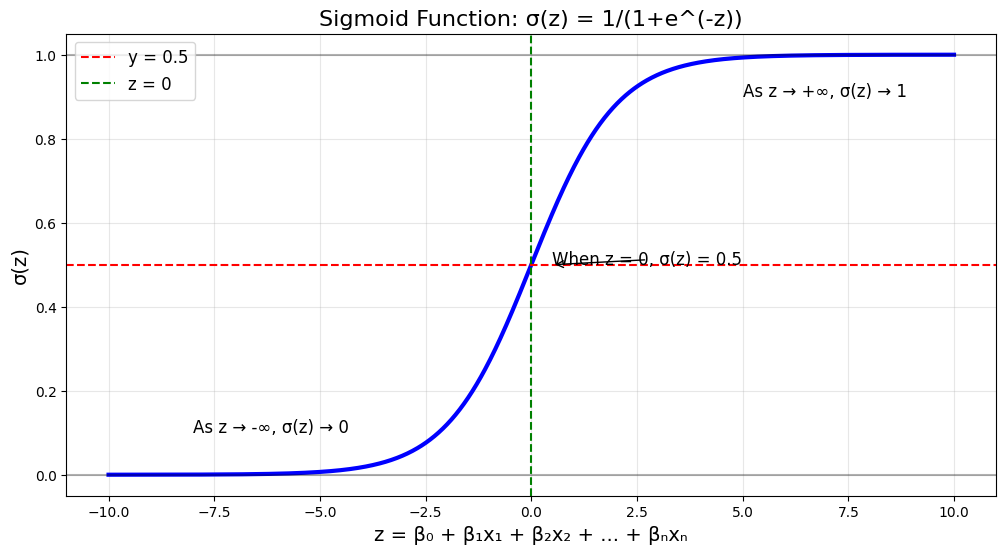

In [15]:
# Plot the sigmoid function
plt.figure(figsize=(12, 6))
xx = np.linspace(-10, 10, 1000)
yy = 1/(1+np.exp(-xx))
plt.plot(xx, yy, 'b-', linewidth=3)
plt.title('Sigmoid Function: σ(z) = 1/(1+e^(-z))', fontsize=16)
plt.xlabel('z = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ', fontsize=14)
plt.ylabel('σ(z)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='r', linestyle='--', label='y = 0.5')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axhline(y=1, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='g', linestyle='--', label='z = 0')
plt.legend(fontsize=12)

# Add annotations
plt.annotate('As z → -∞, σ(z) → 0', xy=(-8, 0.1), fontsize=12)
plt.annotate('As z → +∞, σ(z) → 1', xy=(5, 0.9), fontsize=12)
plt.annotate('When z = 0, σ(z) = 0.5', xy=(0.5, 0.5), fontsize=12, 
             arrowprops=dict(arrowstyle='->'))

Key properties of the sigmoid function:

- If $z$ is very large (positive), then $e^{-z}$ is very small and approaches zero, therefore, $\sigma(z)$ is close to 1.
- If $z$ is very small (negative), then $e^{-z}$ is very large and approaches infinity. Because $\frac{1}{\infty} \approx 0$, we can say that $\sigma(z)$ is close to 0.
- If $z$ is zero, then $e^{-z}$ is 1 and therefore $\sigma(z) = \frac{1}{2}$.

The sigmoid function is differentiable everywhere, which is crucial for optimization algorithms like gradient descent.

We interpret the output of the sigmoid function as the probability that an input belongs to the positive class (class 1). 

For binary classification:
- If $\sigma(z) > 0.5$, we predict class 1
- If $\sigma(z) \leq 0.5$, we predict class 0

This corresponds to the decision boundary where $z = 0$, or equivalently:

$$\beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n = 0$$

This is a linear equation in the feature space, which is why logistic regression is considered a linear model, even though the decision boundary in probability space is non-linear (sigmoid).

One additional point. We can think of this in terms of the following directed acyclic graph (DAG):

<img src="https://www.evernote.com/l/AAE3uJCExaROCKiw2MGh6qZb6C6I8j397bsB/image.png" width=400px>

This diagram shows the flow of information in logistic regression:
1. Input features are combined linearly (weighted sum)
2. The result is passed through the sigmoid function
3. The output is interpreted as a probability

Although the sigmoid function is continuous and differentiable, its non-linearity means we can't solve for the optimal coefficients by setting the derivative of the loss function to zero and solving directly (as we can with linear regression).

Instead, we need to use iterative optimization methods like gradient descent.

## Gradient Descent

Gradient descent is an iterative optimization algorithm used to find the minimum of a function. It's particularly useful when we don't have a closed-form solution for finding the minimum.

While the complete mathematical derivation of gradient descent can be complex, the core idea is straightforward:

The algorithm begins by selecting $\beta$ values at random. The data is passed through the model to obtain predictions, which are used to calculate the loss for the initial $\beta$ values.

<img src="https://www.evernote.com/l/AAF5BGvPeBNMBox9FJiupRrV0ptrd9qlpxQB/image.png" width=600px>

Given the loss value, we calculate the gradient, which tells us the direction of steepest increase in the loss function. The negative of this gradient gives us the direction of steepest decrease.

We then update the $\beta$ values by taking a small step in the direction of the negative gradient:

$$\beta_{new} = \beta_{old} - \alpha \nabla \mathcal{L}(\beta_{old})$$

Where:
- $\alpha$ is the learning rate (step size)
- $\nabla \mathcal{L}(\beta_{old})$ is the gradient of the loss function with respect to $\beta$

Recall that the shape of the loss is a paraboloid. We want to **descend** to the bottom of the loss paraboloid.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/1/12/Paraboloid_of_Revolution.svg/512px-Paraboloid_of_Revolution.svg.png" width=300px>

To do this, we repeatedly:
1. Calculate predictions using current $\beta$ values
2. Calculate the loss
3. Calculate the gradient of the loss
4. Update $\beta$ values using the gradient
5. Repeat until convergence

This process generalizes to more complex models via a process called error or **backward propagation**.

<img src="https://www.evernote.com/l/AAEbw-A7neVFMrX0jUwWViy3ugHFKKND9lkB/image.png" width=800px>

The backward propagation algorithm is the fundamental algorithm for the branch of machine learning known as **deep learning**.

## Summary

In this notebook, we've explored:

1. **Loss Functions**: How linear models are fit by minimizing a loss function, typically the sum of squared errors.

2. **Finding Minima**: How calculus can be used to find the minimum of the loss function for linear regression.

3. **Logistic Regression**: How logistic regression is still a linear model despite using the non-linear sigmoid function.

4. **Gradient Descent**: How iterative optimization can be used when closed-form solutions aren't available.

These concepts form the foundation for more advanced techniques like regularization, which we'll explore in the next notebook. Regularization methods like Ridge and Lasso add penalties to the loss function to prevent overfitting and improve model generalization.